# GlobalCLIP -- 03: Evaluate and Analyse Trained Models

Loads both trained models (Standard and QLayer), evaluates them on the
held-out test set, and generates detailed analysis plots.

**Analyses performed:**
1. Per-sequence Pearson r on log-fold-enrichment (Standard vs QLayer)
2. Protein ranking by mean mixing coefficient α
3. 223×223 α correlation matrix (which proteins co-activate?)
4. Prediction profile comparison (high-signal test examples)
5. QLayer phase polar plot (cooperative vs competitive clusters)
6. QLayer coupling matrix cos(φ_i − φ_j)


## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap
from scipy.stats import pearsonr

from parnet_additional_utils import (
    load_parnet_model,
    ParnetModelName,
)
from globalclip_utils import (
    GlobalCLIPStandardModel,
    GlobalCLIPQLayerModel,
    GlobalCLIPDataset,
    collect_alpha,
    rank_proteins,
    alpha_correlation_matrix,
    evaluate_pearson,
    plot_alpha_heatmap,
    plot_top_proteins,
    plot_phase_polar,
    plot_coupling_heatmap,
    plot_pearson_distribution,
    load_run_config,
)


/home/pgoldemund/pixi-envs/parnet--unified-3311472763523369453/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


### Initialisation

In [2]:
_notebook_name = "03_evaluate_and_analyze.py.ipynb"
_notebook_path = f"notebooks/globalclip/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")


[11:49:45] INFO - Project directory: /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head


### Parameters

In [3]:
params_gpu_index          = 0

# Run IDs from training notebooks (must match params_run_id set there)
params_standard_run_id    = "globalclip.standard.v3"
params_qlayer_run_id      = "globalclip.qlayer.v1"

# Evaluation
params_batch_size         = 128
params_num_workers        = 4
params_n_profile_examples = 5    # how many example profiles to plot

# Analysis
params_top_n_proteins     = 30   # top proteins to show in bar plot
params_phase_label_thresh = 0.0  # label phases with mean_alpha >= this


⏱ 0.00 s (00:00:00)


### Filepaths and device

In [4]:
pylbsr.misc.set_seed(42)

device = torch.device(f"cuda:{params_gpu_index}" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.set_device(params_gpu_index)
    logger.info(f"GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU — running on CPU.")

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.server.yaml").read_text())
pretrained_model_name = ParnetModelName.PARNET_7M_0_0

def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p

FILEPATHS = DotMap()
FILEPATHS.pretrained_model    = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS.standard_run_dir    = PROJECT_DIR / _fp_cfg["results"]["standard_model"] / params_standard_run_id
FILEPATHS.qlayer_run_dir      = PROJECT_DIR / _fp_cfg["results"]["qlayer_model"]   / params_qlayer_run_id
FILEPATHS.analysis_dir        = PROJECT_DIR / _fp_cfg["results"]["analysis"]
FILEPATHS.rbp_names_file      = PROJECT_DIR / "results" / "globalclip" / "datasets" / "rbp_names.txt"
FILEPATHS.analysis_dir.mkdir(parents=True, exist_ok=True)

_std_cfg = load_run_config(FILEPATHS.standard_run_dir)
_qlayer_cfg = load_run_config(FILEPATHS.qlayer_run_dir)
FILEPATHS.dataset = Path(_std_cfg["dataset_path"])

for k, v in FILEPATHS.items():
    logger.info(f"{k:30s}: {v}")


[11:49:45] INFO - GPU: NVIDIA RTX A4000


Seed set to 42


[11:49:45] INFO - pretrained_model              : /mnt/storage1/ml4rg26-shared/parnet-eclip/models-full-rbp-set/parnet.7m-0.0.pt
[11:49:45] INFO - standard_run_dir              : /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/standard/globalclip.standard.v3
[11:49:45] INFO - qlayer_run_dir                : /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/qlayer/globalclip.qlayer.v1
[11:49:45] INFO - analysis_dir                  : /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/analysis
[11:49:45] INFO - rbp_names_file                : /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/datasets/rbp_names.txt
[11:49:45] INFO - dataset                       : /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_noNHS_600bp_signalfiltered.pt.gz


⏱ 0.23 s (00:00:00)


## Load RBP names and test data

In [5]:
rbp_names = FILEPATHS.rbp_names_file.read_text().strip().split("\n")
logger.info(f"Loaded {len(rbp_names)} RBP names.")

test_ds = GlobalCLIPDataset(FILEPATHS.dataset, split="test",
                             seq_len=600, total_key="globalCLIP")
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=params_batch_size, shuffle=False,
    num_workers=params_num_workers, pin_memory=torch.cuda.is_available()
)
logger.info(f"Test set: {len(test_ds)} samples")


[11:49:45] INFO - Loaded 223 RBP names.


Loading (gz) globalclip_lysate_noNHS_600bp_signalfiltered.pt.gz split='test'... loaded 4946 samples.


[11:49:56] INFO - Test set: 4946 samples


⏱ 10.75 s (00:00:10)


## Load trained models

In [6]:
logger.info("Loading pretrained PARNET backbone...")
parnet = load_parnet_model(
    pretrained_model_name,
    FILEPATHS.pretrained_model,
    dtype=torch.float32,
    device=device,
)
parnet.eval()

# ── Standard model ────────────────────────────────────────────────────────────
model_std = GlobalCLIPStandardModel(
    parnet_model=parnet,
    num_rbps=_std_cfg["params_num_rbps"],
    mix_hidden=_std_cfg["params_mix_hidden"],
).to(device)
model_std.load_state_dict(
    torch.load(FILEPATHS.standard_run_dir / "model.statedict.pt", map_location=device)
)
model_std.eval()
logger.info(f"Standard model loaded from {FILEPATHS.standard_run_dir}")

# ── QLayer model ──────────────────────────────────────────────────────────────
model_ql = GlobalCLIPQLayerModel(
    parnet_model=parnet,
    num_rbps=_qlayer_cfg["params_num_rbps"],
    mix_hidden=_qlayer_cfg["params_mix_hidden"],
    cnn_channels=_qlayer_cfg["params_cnn_channels"],
    cnn_kernel=_qlayer_cfg["params_cnn_kernel"],
    cnn_layers=_qlayer_cfg["params_cnn_layers"],
).to(device)
model_ql.load_state_dict(
    torch.load(FILEPATHS.qlayer_run_dir / "model.statedict.pt", map_location=device)
)
model_ql.eval()
logger.info(f"QLayer model loaded from {FILEPATHS.qlayer_run_dir}")


[11:49:56] INFO - Loading pretrained PARNET backbone...
[11:49:56] INFO - Standard model loaded from /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/standard/globalclip.standard.v3
[11:49:56] INFO - QLayer model loaded from /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/qlayer/globalclip.qlayer.v1


⏱ 0.61 s (00:00:00)


## 1 — Test-set Pearson r (Standard vs QLayer)

In [7]:
logger.info("Evaluating Standard model on test set...")
mean_r_std, all_r_std = evaluate_pearson(model_std, test_loader, device)
logger.info(f"Standard   mean Pearson r = {mean_r_std:.4f}  (std={all_r_std.std():.4f})")

logger.info("Evaluating QLayer model on test set...")
mean_r_ql, all_r_ql = evaluate_pearson(model_ql, test_loader, device)
logger.info(f"QLayer     mean Pearson r = {mean_r_ql:.4f}  (std={all_r_ql.std():.4f})")

print(f"\n{'Model':<20s}  {'Mean Pearson r':>15s}  {'Median':>8s}  {'Std':>8s}")
print("-" * 58)
for name, all_r, mean_r in [("Standard", all_r_std, mean_r_std),
                              ("QLayer",   all_r_ql,  mean_r_ql)]:
    print(f"{name:<20s}  {mean_r:>15.4f}  {np.median(all_r):>8.4f}  {all_r.std():>8.4f}")


[11:49:56] INFO - Evaluating Standard model on test set...
/home/pgoldemund/pixi-envs/parnet--unified-3311472763523369453/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[11:50:01] INFO - Standard   mean Pearson r = 0.2656  (std=0.1110)
[11:50:01] INFO - Evaluating QLayer model on test set...
[11:50:05] INFO - QLayer     mean Pearson r = 0.4087  (std=0.1628)



Model                  Mean Pearson r    Median       Std
----------------------------------------------------------
Standard                       0.2656    0.2548    0.1110
QLayer                         0.4087    0.4081    0.1628
⏱ 8.41 s (00:00:08)


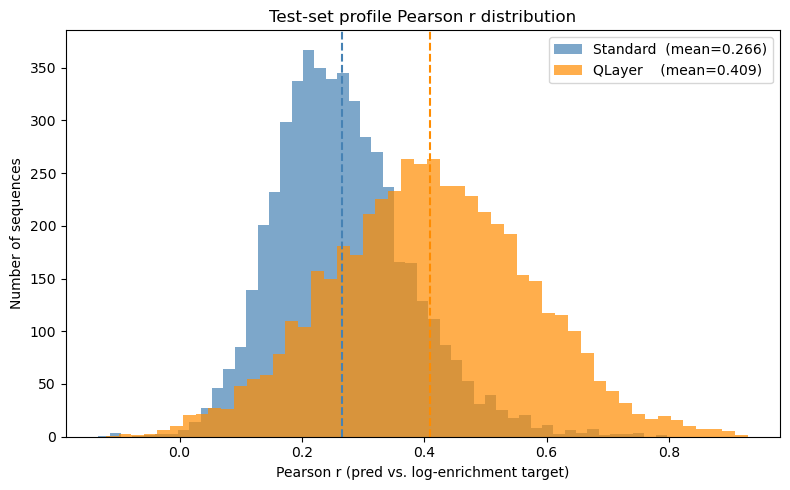

[11:50:05] INFO - Results saved to /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/analysis/test_results.json


⏱ 0.40 s (00:00:00)


In [8]:
fig = plot_pearson_distribution(all_r_std, all_r_ql)
fig.savefig(FILEPATHS.analysis_dir / "pearson_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

# Save numeric results
results = {
    "standard": {"mean_r": float(mean_r_std), "median_r": float(np.median(all_r_std)), "std_r": float(all_r_std.std())},
    "qlayer":   {"mean_r": float(mean_r_ql),  "median_r": float(np.median(all_r_ql)),  "std_r": float(all_r_ql.std())},
}
(FILEPATHS.analysis_dir / "test_results.json").write_text(json.dumps(results, indent=2))
logger.info(f"Results saved to {FILEPATHS.analysis_dir / 'test_results.json'}")


## 2 — Protein ranking by mixing coefficient

Which RBPs contribute most to the GlobalCLIP signal across all test sequences?

In [9]:
logger.info("Collecting alpha matrices (Standard model)...")
alpha_std = collect_alpha(model_std, test_loader, device)
logger.info(f"alpha_std shape: {alpha_std.shape}")

log_scale_std = model_std.log_scale.exp().detach().cpu().numpy()
ranking_std = rank_proteins(alpha_std, rbp_names, log_scale=log_scale_std)

print("Top-20 proteins (Standard model):")
print(ranking_std.head(20).to_string(index=False))


[11:50:05] INFO - Collecting alpha matrices (Standard model)...
[11:50:09] INFO - alpha_std shape: (4946, 223)


Top-20 proteins (Standard model):
 rank      protein   mean_alpha    std_alpha  exp_log_scale  effective_weight
    1 PABPN1_HepG2 1.852035e-01 1.598855e-01       1.142831      2.116563e-01
    2  HNRNPC_K562 1.804353e-01 2.763538e-01       1.048663      1.892159e-01
    3   SND1_HepG2 1.615127e-01 1.019649e-01       1.080644      1.745378e-01
    4    SND1_K562 7.191283e-02 7.558151e-02       1.138170      8.184901e-02
    5  U2AF2_HepG2 5.709907e-02 7.724357e-02       0.937706      5.354214e-02
    6 HNRNPC_HepG2 5.586544e-02 8.648564e-02       1.019440      5.695145e-02
    7   YBX3_HepG2 5.105990e-02 1.021432e-01       0.920271      4.698897e-02
    8  GRWD1_HepG2 3.916267e-02 7.334732e-02       1.050728      4.114932e-02
    9    YBX3_K562 3.548892e-02 5.744885e-02       1.037160      3.680768e-02
   10   NIP7_HepG2 3.481358e-02 3.223360e-02       1.031723      3.591798e-02
   11    HLTF_K562 2.869604e-02 5.596138e-02       1.034739      2.969292e-02
   12  LIN28B_K562 2.467467e-0

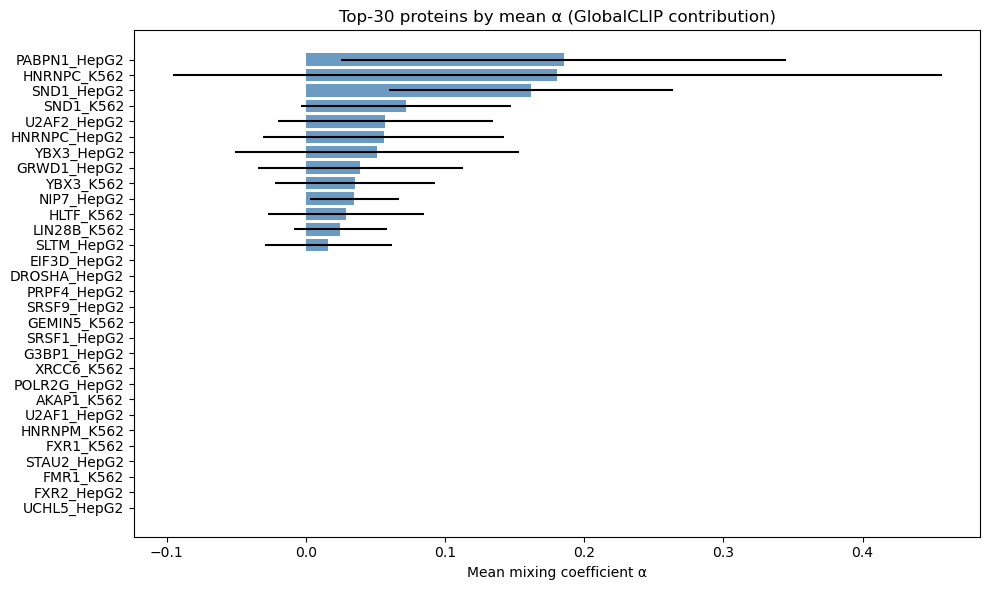

⏱ 0.40 s (00:00:00)


In [10]:
fig = plot_top_proteins(ranking_std, top_n=params_top_n_proteins)
fig.savefig(FILEPATHS.analysis_dir / "protein_ranking_standard.png", dpi=120, bbox_inches="tight")
plt.show()

ranking_std.to_csv(FILEPATHS.analysis_dir / "protein_ranking_standard.tsv", sep="\t", index=False)


## 3 — Alpha correlation matrix

Proteins with correlated mixing coefficients tend to co-activate on the same
sequences — they likely belong to the same RNP complex or bind related motifs.

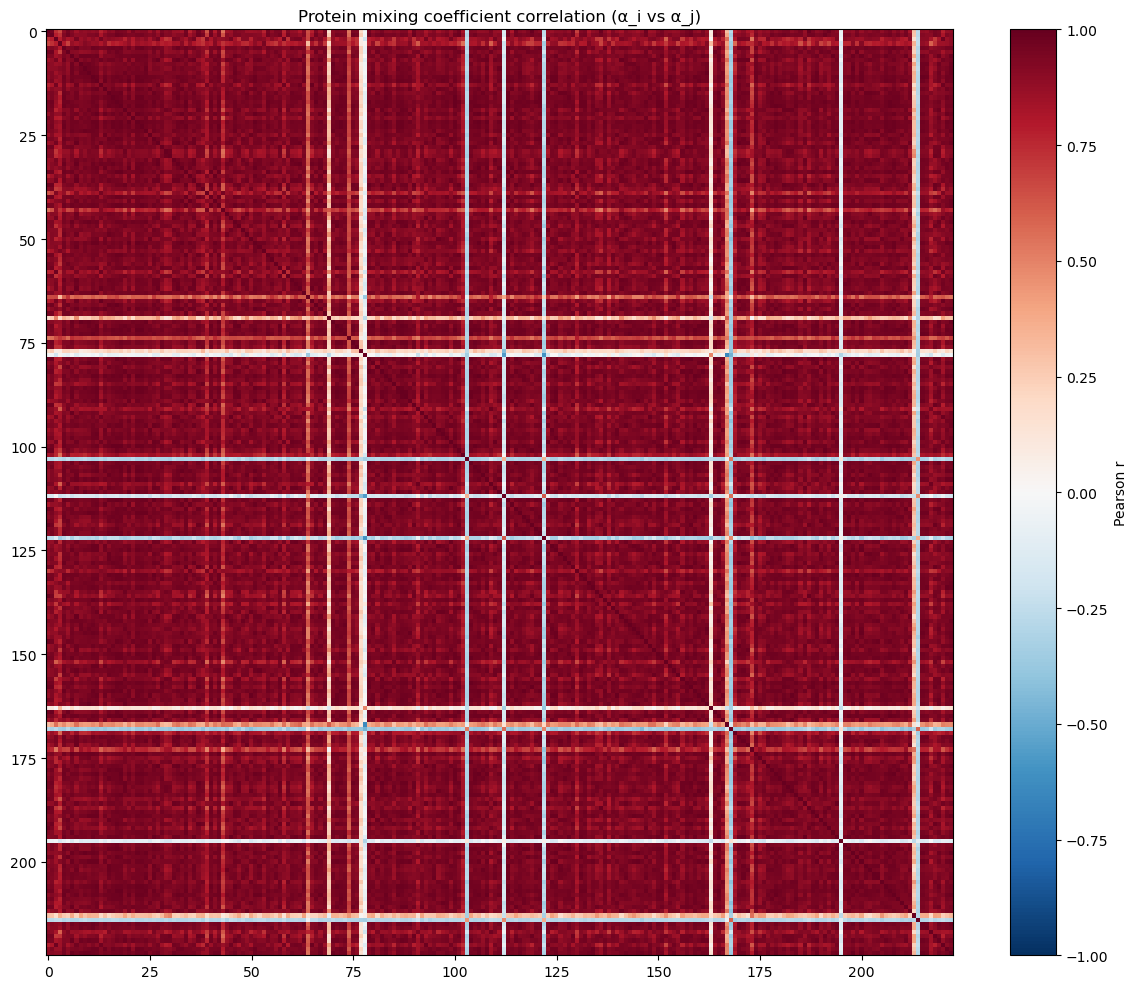

Top-10 most correlated protein pairs (Standard model):
      r  Protein A                  Protein B
-----------------------------------------------------------------
  0.992  HNRNPM_HepG2               MATR3_HepG2
  0.992  HNRNPL_K562                TAF15_HepG2
  0.992  HNRNPK_K562                SLBP_K562
  0.992  CSTF2T_K562                DDX6_K562
  0.992  CSTF2T_K562                FAM120A_K562
  0.991  DHX30_K562                 IGF2BP1_K562
  0.991  LARP4_K562                 NCBP2_HepG2
  0.991  SAFB_K562                  SF3A3_HepG2
  0.991  DDX24_K562                 HNRNPM_HepG2
  0.991  CPSF6_K562                 NIPBL_K562
⏱ 0.60 s (00:00:00)


In [11]:
corr_std = alpha_correlation_matrix(alpha_std)

fig = plot_alpha_heatmap(corr_std, rbp_names=None)   # too many names for labels
fig.savefig(FILEPATHS.analysis_dir / "alpha_correlation_standard.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-10 most correlated pairs (excluding self)
idx = np.triu_indices(223, k=1)
pairs = [(corr_std[i, j], rbp_names[i], rbp_names[j])
         for i, j in zip(idx[0], idx[1])]
pairs.sort(key=lambda x: abs(x[0]), reverse=True)
print("Top-10 most correlated protein pairs (Standard model):")
print(f"{'r':>7s}  {'Protein A':<25s}  {'Protein B'}")
print("-" * 65)
for r, a, b in pairs[:10]:
    print(f"{r:>7.3f}  {a:<25s}  {b}")


## 4 — Prediction profiles (high-signal examples)

Select the test sequences with the highest total GlobalCLIP signal and compare
the ground truth log-FE against both model predictions.

In [12]:
# Collect all signal totals to find high-signal sequences
from globalclip_utils.datasets import GlobalCLIPDataset

signal_totals = []
with torch.no_grad():
    for batch in test_loader:
        signal_totals.extend(batch["signal"].squeeze(1).sum(-1).tolist())
signal_totals = np.array(signal_totals)
top_indices = signal_totals.argsort()[::-1][:params_n_profile_examples]
logger.info(f"Top-{params_n_profile_examples} signal totals: {signal_totals[top_indices]}")


[11:50:13] INFO - Top-5 signal totals: [12773.  5121.  2882.  2649.  2625.]


⏱ 3.49 s (00:00:03)


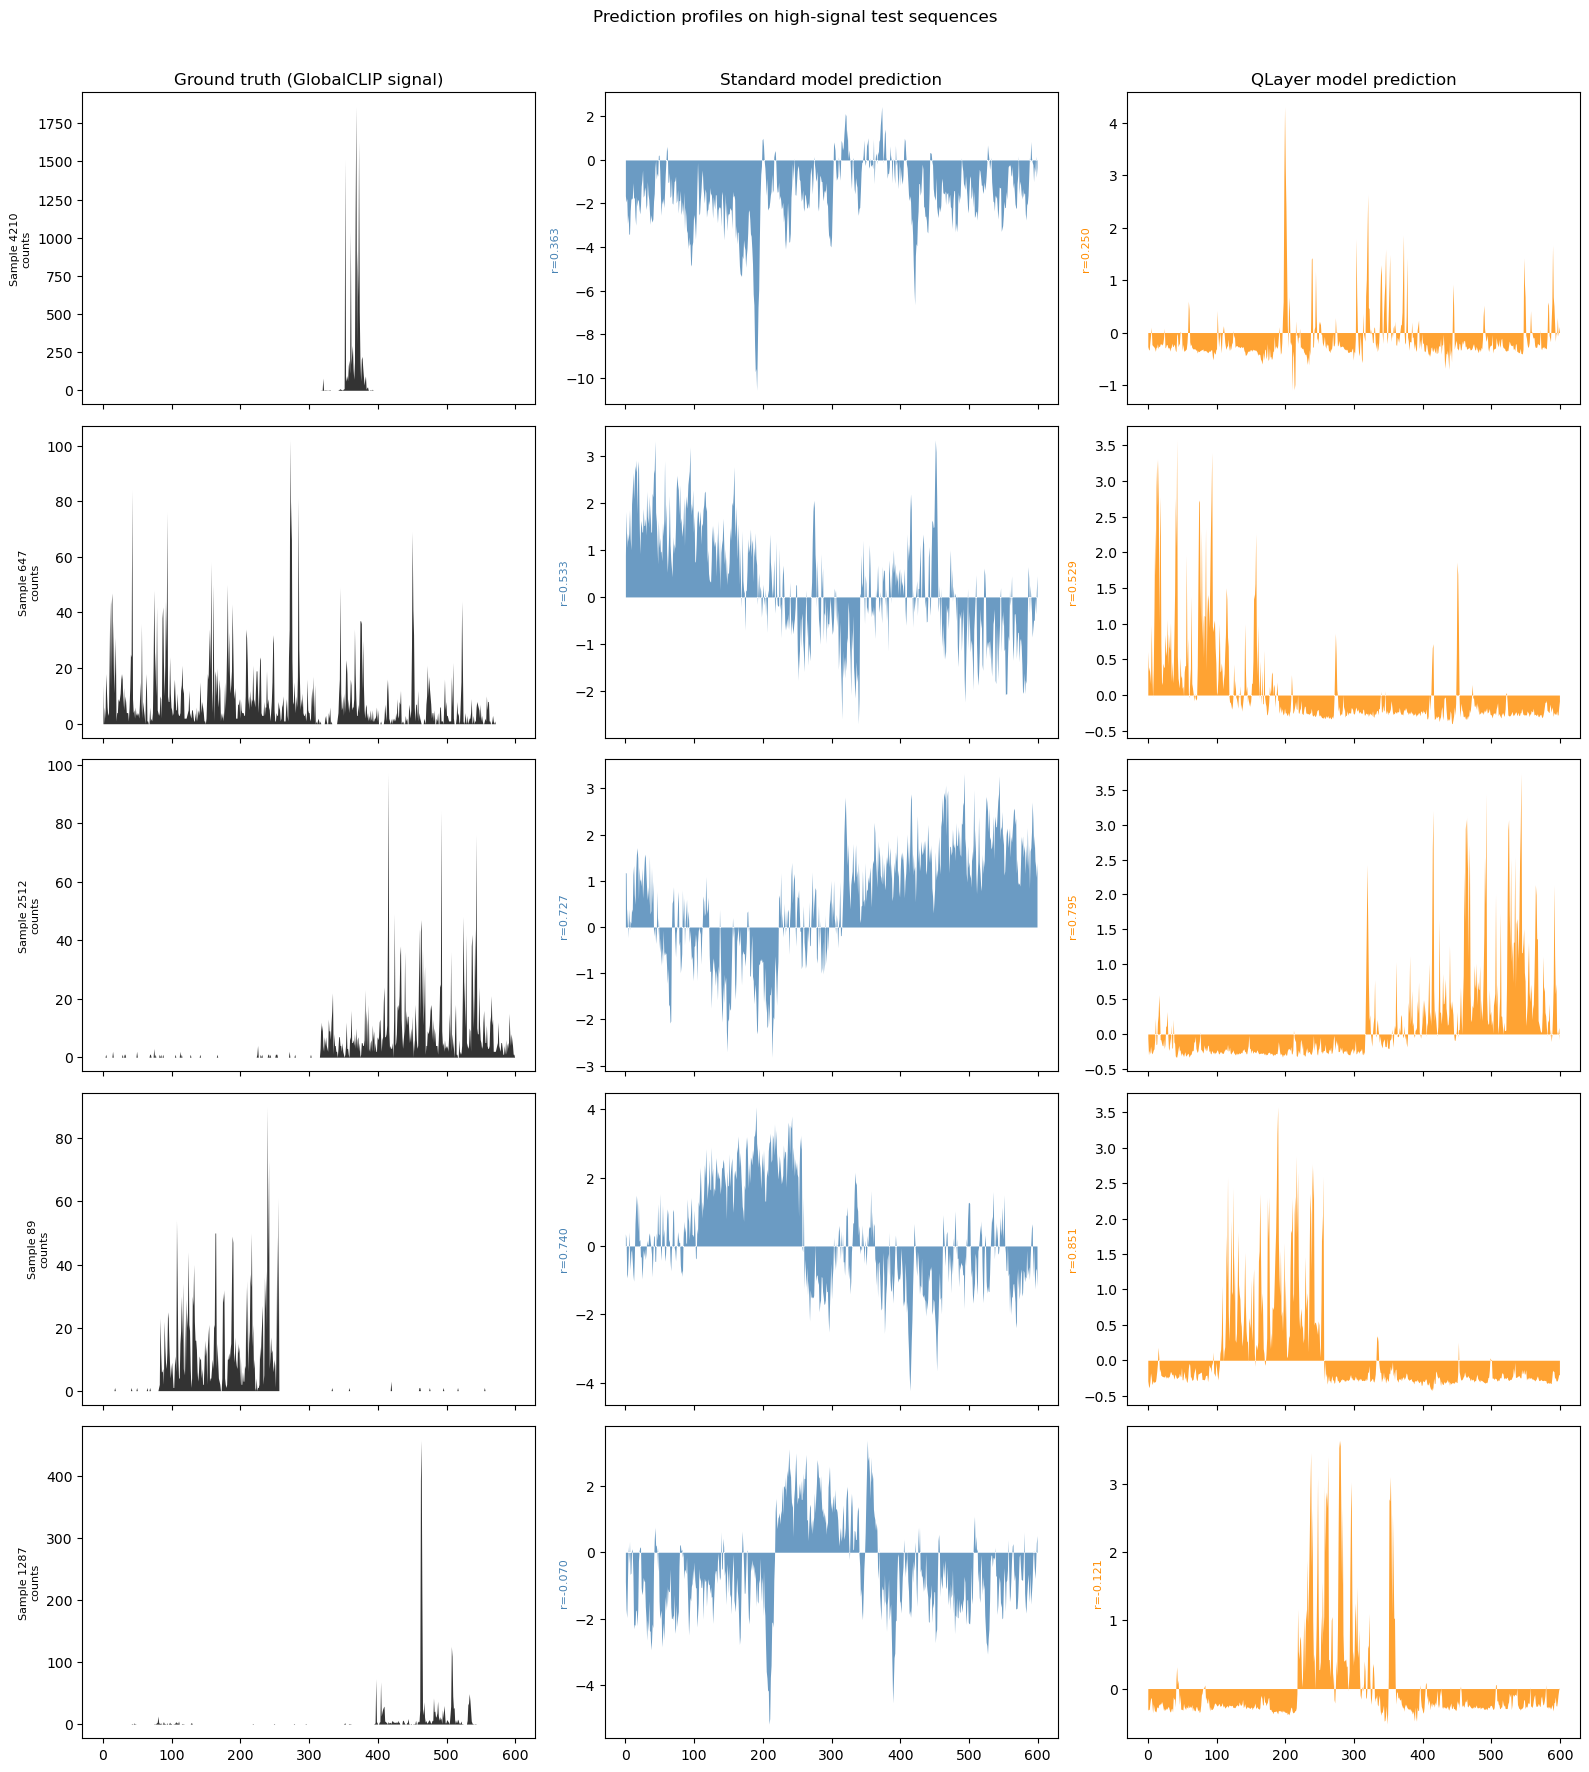

⏱ 2.09 s (00:00:02)


In [13]:
fig, axes = plt.subplots(params_n_profile_examples, 3,
                          figsize=(16, 3.5 * params_n_profile_examples),
                          sharex=True)

with torch.no_grad():
    for row, idx in enumerate(top_indices):
        sample    = test_ds[idx]
        seq       = sample["sequence"].unsqueeze(0).to(device)
        signal    = sample["signal"]

        target    = torch.log1p(signal).squeeze().numpy()
        signal_np = signal.squeeze().numpy()

        pred_std, _ = model_std(seq)
        pred_ql,  _ = model_ql(seq)
        pred_std_np = pred_std.squeeze().cpu().numpy()
        pred_ql_np  = pred_ql.squeeze().cpu().numpy()

        r_std, _ = pearsonr(pred_std_np, target)
        r_ql,  _ = pearsonr(pred_ql_np,  target)

        pos = np.arange(600)
        kw  = dict(linewidth=0, alpha=0.8)

        axes[row, 0].fill_between(pos, signal_np, color="black", **kw)
        axes[row, 0].set_ylabel(f"Sample {idx}\ncounts", fontsize=8)
        if row == 0:
            axes[row, 0].set_title("Ground truth (GlobalCLIP signal)")

        axes[row, 1].fill_between(pos, pred_std_np, color="steelblue", **kw)
        axes[row, 1].set_ylabel(f"r={r_std:.3f}", fontsize=8, color="steelblue")
        if row == 0:
            axes[row, 1].set_title("Standard model prediction")

        axes[row, 2].fill_between(pos, pred_ql_np, color="darkorange", **kw)
        axes[row, 2].set_ylabel(f"r={r_ql:.3f}", fontsize=8, color="darkorange")
        if row == 0:
            axes[row, 2].set_title("QLayer model prediction")

plt.suptitle("Prediction profiles on high-signal test sequences", y=1.01)
plt.tight_layout()
plt.savefig(FILEPATHS.analysis_dir / "profile_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 5 — QLayer phase analysis

After training, each of the 223 proteins has a learned phase φ_i.
Proteins clustered at similar phases cooperate (constructive interference);
proteins at opposite phases compete or cancel (destructive interference —
the mechanism by which the QLayer suppresses background noise).

In [14]:
logger.info("Collecting alpha for QLayer model...")
alpha_ql = collect_alpha(model_ql, test_loader, device)
ranking_ql = rank_proteins(alpha_ql, rbp_names)

phases = model_ql.qlayer.phase.detach().cpu().numpy()
mean_alpha_ql = alpha_ql.mean(0)

print(f"Phase range: [{phases.min():.3f}, {phases.max():.3f}] rad")
print(f"Phase std:   {phases.std():.3f} rad")

# Label the most important proteins
params_phase_label_thresh = float(np.percentile(mean_alpha_ql, 80))
print(f"Labeling proteins with mean_alpha >= {params_phase_label_thresh:.4f} (top 20%)")


[11:50:15] INFO - Collecting alpha for QLayer model...


Phase range: [0.000, 0.000] rad
Phase std:   0.000 rad
Labeling proteins with mean_alpha >= 0.0000 (top 20%)
⏱ 3.79 s (00:00:03)


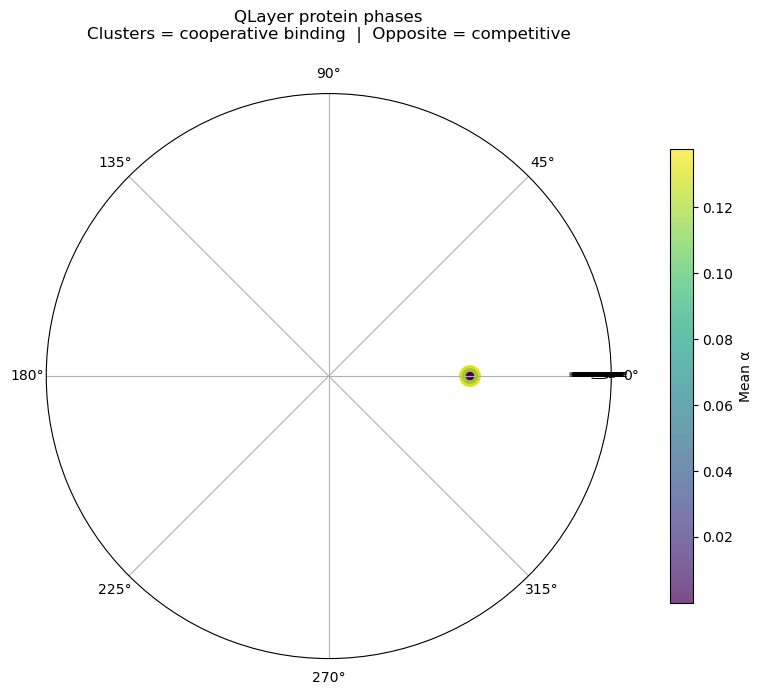

⏱ 0.52 s (00:00:00)


In [15]:
fig = plot_phase_polar(
    phases=phases,
    rbp_names=rbp_names,
    label_threshold=params_phase_label_thresh,
    alpha_values=mean_alpha_ql,
)
fig.savefig(FILEPATHS.analysis_dir / "qlayer_phase_polar.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# Phase-sorted protein table
phase_df = pd.DataFrame({
    "protein":    rbp_names,
    "phase_rad":  phases,
    "mean_alpha": mean_alpha_ql,
}).sort_values("phase_rad").reset_index(drop=True)

print("Proteins sorted by phase (head = most constructive, tail = most destructive):")
print(phase_df[["protein","phase_rad","mean_alpha"]].head(10).to_string(index=False))
print("...")
print(phase_df[["protein","phase_rad","mean_alpha"]].tail(10).to_string(index=False))

phase_df.to_csv(FILEPATHS.analysis_dir / "qlayer_phases.tsv", sep="\t", index=False)


Proteins sorted by phase (head = most constructive, tail = most destructive):
      protein  phase_rad   mean_alpha
   XPO5_HepG2        0.0 1.526406e-09
  XRCC6_HepG2        0.0 2.037061e-09
   XRCC6_K562        0.0 1.810859e-09
   XRN2_HepG2        0.0 1.051259e-09
    XRN2_K562        0.0 8.579532e-10
   YBX3_HepG2        0.0 1.262356e-08
    YBX3_K562        0.0 1.292897e-01
   YWHAG_K562        0.0 7.382292e-10
ZC3H11A_HepG2        0.0 8.005298e-10
    AATF_K562        0.0 8.855169e-10
...
     protein  phase_rad   mean_alpha
 BUD13_HepG2        0.0 4.940875e-10
  BUD13_K562        0.0 8.003436e-10
 CDC40_HepG2        0.0 3.788418e-10
ZC3H11A_K562        0.0 7.612664e-10
  ZC3H8_K562        0.0 1.389524e-09
 ZNF622_K562        0.0 1.062008e-03
ZNF800_HepG2        0.0 1.000396e-09
 ZNF800_K562        0.0 2.974849e-09
 ZRANB2_K562        0.0 1.808402e-09
   AARS_K562        0.0 1.603317e-09
⏱ 0.03 s (00:00:00)


## 6 — QLayer coupling matrix

`cos(φ_i − φ_j)`: +1 = fully cooperative, −1 = fully competitive.

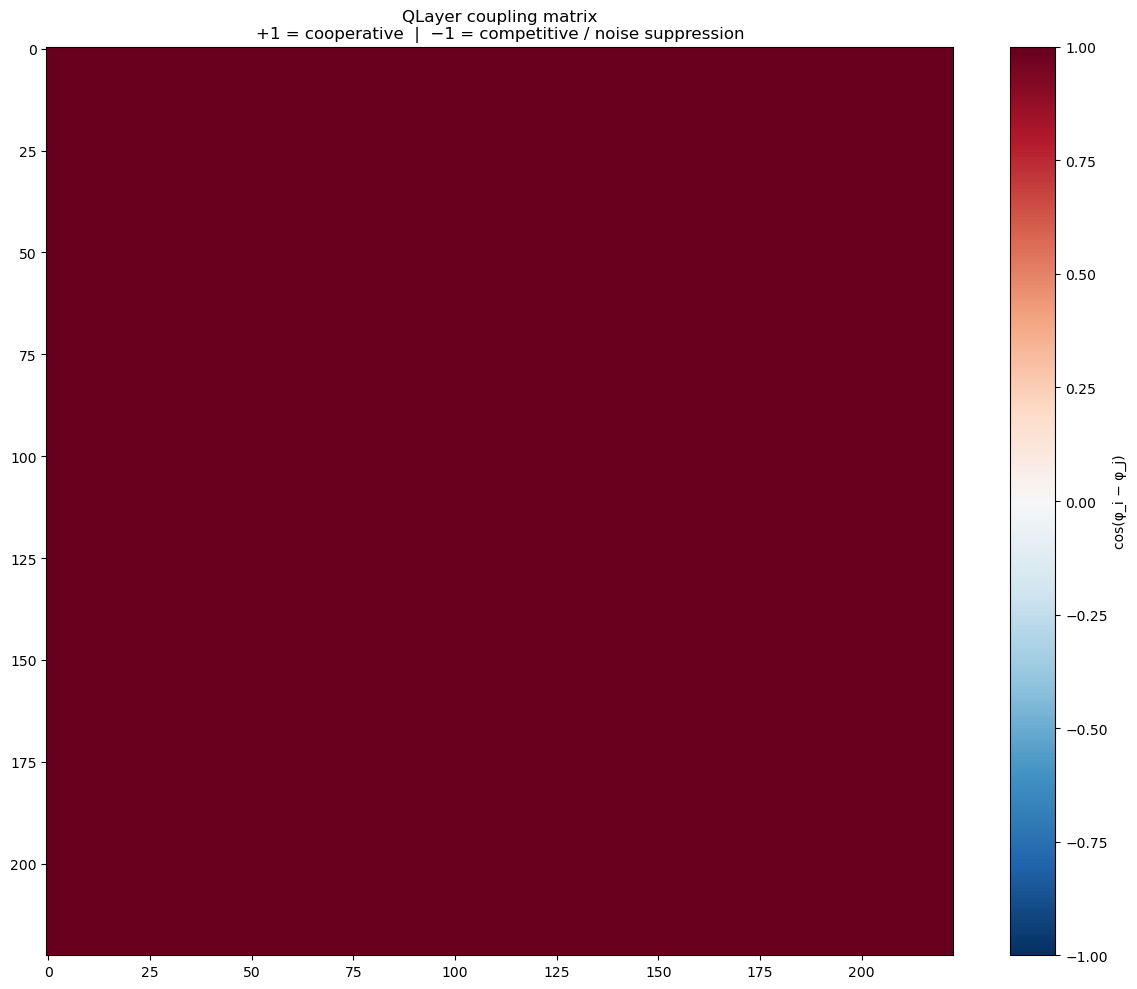

Top-10 cooperative protein pairs (cos(φ_i−φ_j) ≈ 1):
  cos(Δφ)=+1.000  AARS_K562  ↔  AATF_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  ABCF1_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  AGGF1_HepG2
  cos(Δφ)=+1.000  AARS_K562  ↔  AGGF1_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  AKAP1_HepG2
  cos(Δφ)=+1.000  AARS_K562  ↔  AKAP1_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  AKAP8L_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  APOBEC3C_K562
  cos(Δφ)=+1.000  AARS_K562  ↔  AQR_HepG2
  cos(Δφ)=+1.000  AARS_K562  ↔  AQR_K562

Top-10 competitive protein pairs (cos(φ_i−φ_j) ≈ −1):
  cos(Δφ)=+1.000  ZNF800_K562  ↔  ZRANB2_K562
  cos(Δφ)=+1.000  ZNF800_HepG2  ↔  ZRANB2_K562
  cos(Δφ)=+1.000  ZNF800_HepG2  ↔  ZNF800_K562
  cos(Δφ)=+1.000  ZNF622_K562  ↔  ZRANB2_K562
  cos(Δφ)=+1.000  ZNF622_K562  ↔  ZNF800_K562
  cos(Δφ)=+1.000  ZNF622_K562  ↔  ZNF800_HepG2
  cos(Δφ)=+1.000  ZC3H8_K562  ↔  ZRANB2_K562
  cos(Δφ)=+1.000  ZC3H8_K562  ↔  ZNF800_K562
  cos(Δφ)=+1.000  ZC3H8_K562  ↔  ZNF800_HepG2
  cos(Δφ)=+1.000  ZC3H8_K562  ↔  ZNF622_K562


In [17]:
coupling = model_ql.get_coupling_matrix().cpu().numpy()

fig = plot_coupling_heatmap(coupling)
fig.savefig(FILEPATHS.analysis_dir / "qlayer_coupling.png", dpi=150, bbox_inches="tight")
plt.show()

# Top cooperative pairs
idx = np.triu_indices(223, k=1)
coup_pairs = [(coupling[i, j], rbp_names[i], rbp_names[j])
              for i, j in zip(idx[0], idx[1])]
coup_pairs.sort(key=lambda x: x[0], reverse=True)

print("Top-10 cooperative protein pairs (cos(φ_i−φ_j) ≈ 1):")
for c, a, b in coup_pairs[:10]:
    print(f"  cos(Δφ)={c:+.3f}  {a}  ↔  {b}")

print("\nTop-10 competitive protein pairs (cos(φ_i−φ_j) ≈ −1):")
for c, a, b in coup_pairs[-10:][::-1]:
    print(f"  cos(Δφ)={c:+.3f}  {a}  ↔  {b}")


## 7 — QLayer alpha correlation (comparison with Standard)

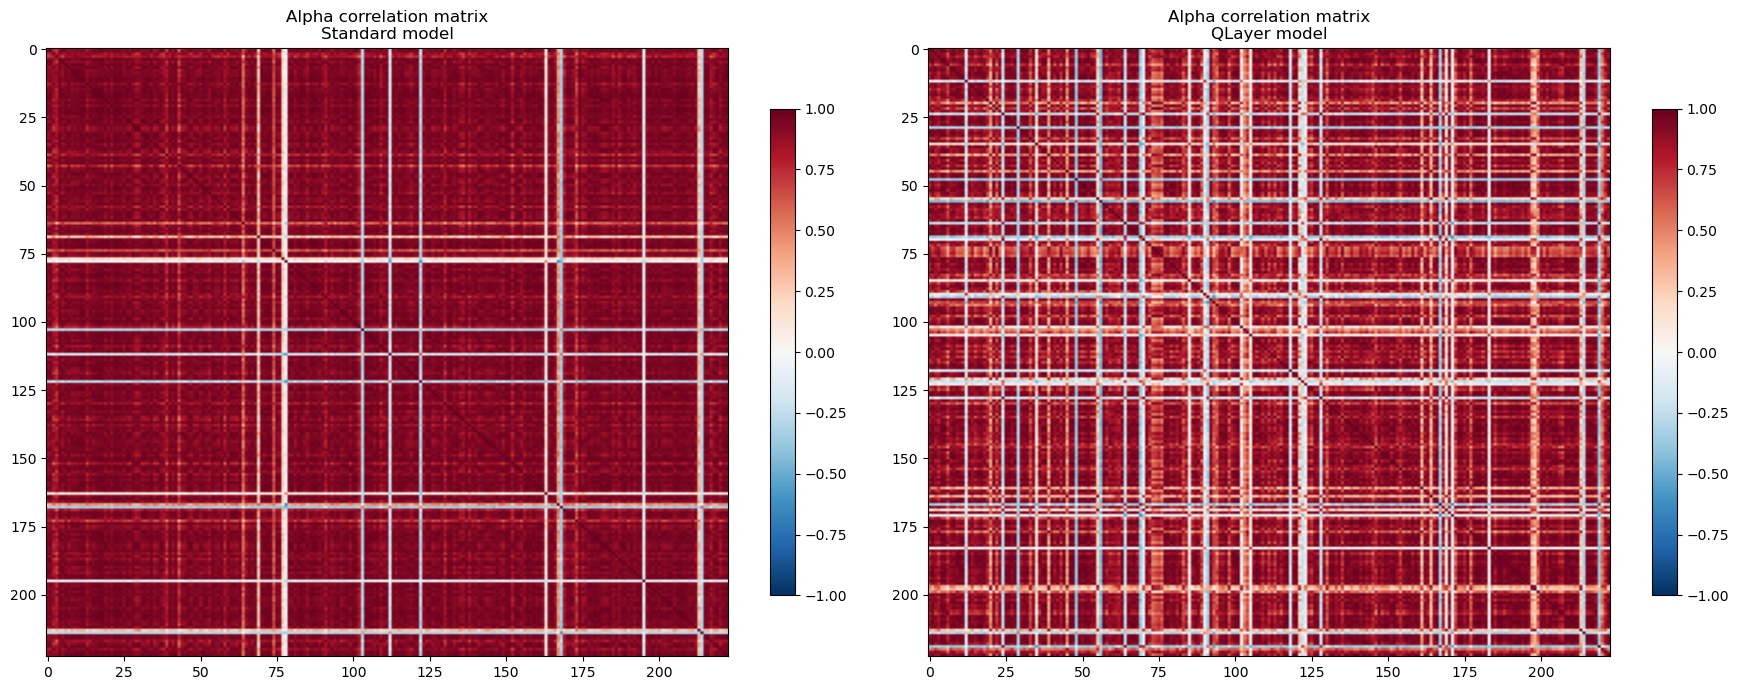

⏱ 0.97 s (00:00:00)


In [18]:
corr_ql = alpha_correlation_matrix(alpha_ql)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, corr, name in [
    (axes[0], corr_std, "Standard model"),
    (axes[1], corr_ql,  "QLayer model"),
]:
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"Alpha correlation matrix\n{name}")

plt.tight_layout()
plt.savefig(FILEPATHS.analysis_dir / "alpha_correlation_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary table

In [19]:
summary = pd.DataFrame([
    {
        "Model":           "Standard (MixCoeffHead + log_scale)",
        "Trainable params": sum(p.numel() for p in model_std.parameters() if p.requires_grad),
        "Mean Pearson r":   f"{mean_r_std:.4f}",
        "Median Pearson r": f"{np.median(all_r_std):.4f}",
    },
    {
        "Model":           "QLayer (QLayer + dilated CNN)",
        "Trainable params": sum(p.numel() for p in model_ql.parameters() if p.requires_grad),
        "Mean Pearson r":   f"{mean_r_ql:.4f}",
        "Median Pearson r": f"{np.median(all_r_ql):.4f}",
    },
])

print("\n=== EVALUATION SUMMARY ===")
print(summary.to_string(index=False))
print("\nAll plots saved to:", FILEPATHS.analysis_dir)



=== EVALUATION SUMMARY ===
                              Model  Trainable params Mean Pearson r Median Pearson r
Standard (MixCoeffHead + log_scale)             94654         0.2656           0.2548
      QLayer (QLayer + dilated CNN)            169438         0.4087           0.4081

All plots saved to: /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/analysis
⏱ 0.00 s (00:00:00)


## 8 — Naive baseline & statistical significance

Is the learned combination (Standard / QLayer) actually better than "the
original model" — i.e. the frozen PARNET backbone's 223 raw RBP tracks with
no learned weighting at all? We compare against a naive baseline (uniform
mean of the raw tracks) and test whether any improvement is statistically
significant, not just a difference in the mean.

In [20]:
import torch.nn as nn


class NaiveBaselineModel(nn.Module):
    """Un-learned baseline: uniform-weighted mean of the 223 raw PARNET RBP tracks.

    Represents "the original model" with no GlobalCLIP combination layer at
    all -- same frozen backbone, but no learned alpha / log_scale / QLayer.
    """

    def __init__(self, parnet_model: nn.Module, num_rbps: int = 223):
        super().__init__()
        self.backbone = parnet_model
        self.num_rbps = num_rbps

    @torch.no_grad()
    def forward(self, seq_onehot: torch.Tensor):
        x = self.backbone.stem(seq_onehot)
        x = self.backbone.body(x)
        if hasattr(self.backbone, "projection"):
            x = self.backbone.projection(x)
        rbp_tracks = self.backbone.head.head_target.pointwise_conv(x)   # (B, 223, L)
        pred = rbp_tracks.mean(dim=1, keepdim=True)                     # (B, 1, L)
        alpha = torch.full(
            (seq_onehot.shape[0], self.num_rbps),
            1.0 / self.num_rbps,
            device=seq_onehot.device,
        )
        return pred, alpha


model_base = NaiveBaselineModel(parnet, num_rbps=223).to(device)

logger.info("Evaluating naive baseline (uniform mean of raw RBP tracks) on test set...")
mean_r_base, all_r_base = evaluate_pearson(model_base, test_loader, device)
logger.info(f"Baseline   mean Pearson r = {mean_r_base:.4f}  (std={all_r_base.std():.4f})")

print(f"\n{'Model':<20s}  {'Mean Pearson r':>15s}  {'Median':>8s}  {'Std':>8s}")
print("-" * 58)
for name, all_r, mean_r in [
    ("Baseline (naive)", all_r_base, mean_r_base),
    ("Standard",         all_r_std,  mean_r_std),
    ("QLayer",           all_r_ql,   mean_r_ql),
]:
    print(f"{name:<20s}  {mean_r:>15.4f}  {np.median(all_r):>8.4f}  {all_r.std():>8.4f}")

[11:50:21] INFO - Evaluating naive baseline (uniform mean of raw RBP tracks) on test set...
[11:50:25] INFO - Baseline   mean Pearson r = 0.1892  (std=0.0880)



Model                  Mean Pearson r    Median       Std
----------------------------------------------------------
Baseline (naive)               0.1892    0.1788    0.0880
Standard                       0.2656    0.2548    0.1110
QLayer                         0.4087    0.4081    0.1628
⏱ 3.69 s (00:00:03)


In [21]:
from scipy.stats import wilcoxon


def paired_significance(name_a, r_a, name_b, r_b):
    """Paired Wilcoxon signed-rank test on per-sequence Pearson r (same test set)."""
    stat, p = wilcoxon(r_b, r_a)
    diff = r_b.mean() - r_a.mean()
    print(f"{name_b:<10s} vs {name_a:<18s}: mean Δr = {diff:+.4f}   Wilcoxon p = {p:.2e}")
    return p


print("=== Paired significance tests (per-sequence Pearson r, same test sequences) ===")
p_base_std = paired_significance("Baseline", all_r_base, "Standard", all_r_std)
p_base_ql  = paired_significance("Baseline", all_r_base, "QLayer",   all_r_ql)
p_std_ql   = paired_significance("Standard", all_r_std,  "QLayer",   all_r_ql)

=== Paired significance tests (per-sequence Pearson r, same test sequences) ===
Standard   vs Baseline          : mean Δr = +0.0765   Wilcoxon p = 0.00e+00
QLayer     vs Baseline          : mean Δr = +0.2195   Wilcoxon p = 0.00e+00
QLayer     vs Standard          : mean Δr = +0.1430   Wilcoxon p = 0.00e+00
⏱ 0.01 s (00:00:00)


In [22]:
def bootstrap_mean_diff_ci(r_a, r_b, n_boot=10000, seed=42):
    """95% bootstrap CI for the mean paired difference (r_b - r_a)."""
    rng = np.random.default_rng(seed)
    diffs = r_b - r_a
    n = len(diffs)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = diffs[idx].mean(axis=1)
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return diffs.mean(), lo, hi


print("=== Bootstrap 95% CI for mean Δr (10000 resamples) ===")
for name_a, r_a, name_b, r_b in [
    ("Baseline", all_r_base, "Standard", all_r_std),
    ("Baseline", all_r_base, "QLayer",   all_r_ql),
    ("Standard", all_r_std,  "QLayer",   all_r_ql),
]:
    mean_diff, lo, hi = bootstrap_mean_diff_ci(r_a, r_b)
    sig = "significant" if lo > 0 or hi < 0 else "not significant"
    print(f"{name_b:<10s} - {name_a:<10s}: Δr = {mean_diff:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  ({sig})")

=== Bootstrap 95% CI for mean Δr (10000 resamples) ===
Standard   - Baseline  : Δr = +0.0765  95% CI [+0.0747, +0.0782]  (significant)
QLayer     - Baseline  : Δr = +0.2195  95% CI [+0.2161, +0.2229]  (significant)
QLayer     - Standard  : Δr = +0.1430  95% CI [+0.1407, +0.1454]  (significant)
⏱ 1.11 s (00:00:01)


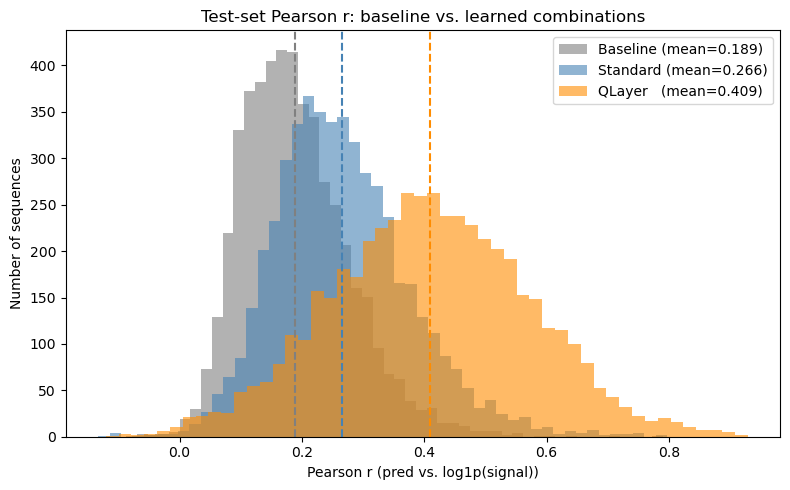

[11:50:27] INFO - Updated results (with baseline + significance) saved to /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head/results/globalclip/analysis/test_results.json


⏱ 0.42 s (00:00:00)


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
kw = dict(bins=50, alpha=0.6, edgecolor="none")
for all_r, label, color in [
    (all_r_base, f"Baseline (mean={mean_r_base:.3f})", "gray"),
    (all_r_std,  f"Standard (mean={mean_r_std:.3f})",  "steelblue"),
    (all_r_ql,   f"QLayer   (mean={mean_r_ql:.3f})",   "darkorange"),
]:
    ax.hist(all_r, label=label, color=color, **kw)
    ax.axvline(all_r.mean(), color=color, linestyle="--", linewidth=1.5)
ax.set_xlabel("Pearson r (pred vs. log1p(signal))")
ax.set_ylabel("Number of sequences")
ax.set_title("Test-set Pearson r: baseline vs. learned combinations")
ax.legend()
plt.tight_layout()
fig.savefig(FILEPATHS.analysis_dir / "pearson_distribution_with_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

# Update saved results with baseline + significance
results_with_baseline = {
    "baseline": {"mean_r": float(mean_r_base), "median_r": float(np.median(all_r_base)), "std_r": float(all_r_base.std())},
    "standard": {"mean_r": float(mean_r_std),  "median_r": float(np.median(all_r_std)),  "std_r": float(all_r_std.std())},
    "qlayer":   {"mean_r": float(mean_r_ql),   "median_r": float(np.median(all_r_ql)),   "std_r": float(all_r_ql.std())},
    "significance_wilcoxon_p": {
        "standard_vs_baseline": float(p_base_std),
        "qlayer_vs_baseline":   float(p_base_ql),
        "qlayer_vs_standard":   float(p_std_ql),
    },
}
(FILEPATHS.analysis_dir / "test_results.json").write_text(json.dumps(results_with_baseline, indent=2))
logger.info(f"Updated results (with baseline + significance) saved to {FILEPATHS.analysis_dir / 'test_results.json'}")